In [91]:
from qutip import * 
from qutip.core.gates import toffoli
import numpy as np
import matplotlib.pyplot as plt

d:\ScienceAPPs\Anaconda\envs\Quantum_tools_in_python\Lib\site-packages\qutip\solver\solver_base.py:598: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


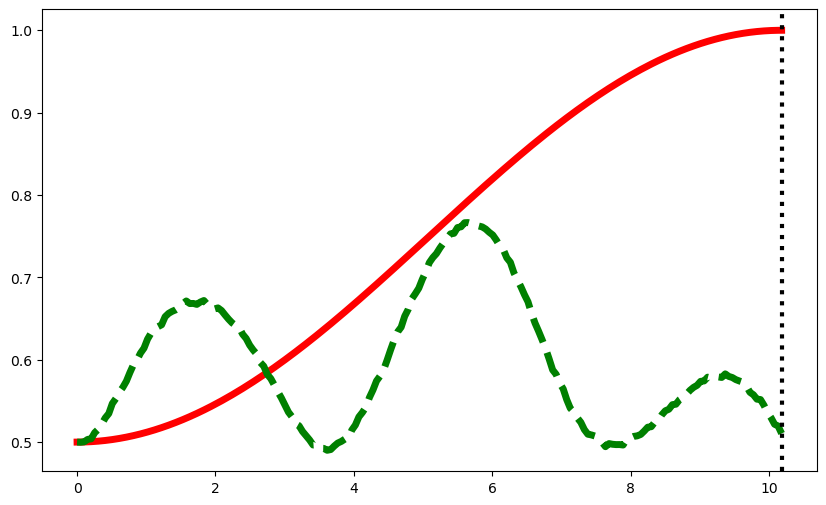

In [92]:
# ============================================================
# FIG.1 Fidelitis of quantum Toffoli Gate plotted with H_{full} and H_{eff}
# ============================================================

# ============================================================
# 1.1参数设置
# ============================================================


gamma = 0
gamma_A = 0
Omega_r = 2 * np.pi * (20 / 3) ##试验值
Omega_A= 3.25 * Omega_r

Delta_r = 12 * Omega_r
# Delta_A = 

V = Delta_r - (Omega_r**2)/(3*Delta_r) ##计算得到的RRI V满足的反阻塞条件
g= (3*Omega_r**3)/(4*Delta_r**2) ##H_EFF中耦合系数
t_g = (2*np.sqrt(2)*np.pi*Delta_r**2)/(3*Omega_r**3) ##计算得到的Toffoli门实现时间

t_list = np.linspace(0, t_g, 201)

# ============================================================
# 1.2 基矢|ijk>...|lmn>定义，外积|ijk><lmn|定义
# ============================================================

N = 4
i0, i1, iA, ir = 0, 1, 2, 3

def ket(i, j, k):
    return tensor(basis(N, i), basis(N, j), basis(N,k))

def P(i, j, k, l, m, n):
    return ket(i, j, k) * ket(l, m, n).dag()

# ============================================================
# 1.3 H_eff 和  H_full定义
# ============================================================

def H_eff(g):
    H_eff = g * (
    P(i1,i1,i0,ir,ir,ir) + P(i1,i1,i1,ir,ir,ir) +
    P(ir,ir,ir,i1,i1,i0) + P(ir,ir,ir,i1,i1,i1))
    return H_eff


def H_full(Omega_r, Delta_r):

    H_full = 0

    H_plus = P(i0,i0,i0,i0,i0,ir)+P(i0,i0,i1,i0,i0,ir)+P(i0,i1,i0,i0,i1,ir)+P(i0,i1,i0,i0,ir,i0)+P(i0,i1,i1,i0,i1,ir)+P(i0,i1,i1,i0,ir,i1)+P(i0,ir,ir,i0,i1,ir)+P(i0,ir,ir,i0,ir,i0)+P(i0,ir,ir,i0,ir,i1)+P(i1,i0,i0,i1,i0,ir)+P(i1,i0,i0,ir,i0,i0)+P(i1,i0,i1,i1,i0,ir)+P(i1,i0,i1,ir,i0,i1)+P(i1,i1,i0,i1,i1,ir)+P(i1,i1,i0,i1,ir,i0)+P(i1,i1,i0,ir,i1,i0)+P(i1,i1,i1,i1,i1,ir)+P(i1,i1,i1,i1,ir,i1)+P(i1,i1,i1,ir,i1,i1)+P(i1,ir,ir,i1,i1,ir)+P(i1,ir,ir,i1,ir,i0)+P(i1,ir,ir,i1,ir,i1)+P(ir,i0,ir,i1,i0,ir)+P(ir,i0,ir,ir,i0,i0)+P(ir,i0,ir,ir,i0,i1)+P(ir,i1,ir,i1,i1,ir)+P(ir,i1,ir,ir,i1,i0)+P(ir,i1,ir,ir,i1,i1)+P(ir,ir,i0,i1,ir,ir)+P(ir,ir,i0,ir,i1,ir)+P(ir,ir,i1,i1,ir,ir)+P(ir,ir,i1,ir,i1,ir)

    H_minus = H_plus.dag()
    H_td = [
        [(Omega_r/2)*H_plus,  lambda t, args: np.exp(1j * Delta_r * t)],
        [(Omega_r/2)*H_minus,  lambda t, args: np.exp(-1j * Delta_r * t)]
    ]

    H_rrr_plus = (Omega_r/2)*(P(i1,ir,ir,ir,ir,ir)+P(ir,i1,ir,ir,ir,ir)+P(ir,ir,i0,ir,ir,ir))
    H_rrr_minus = H_rrr_plus.dag()
    H_rrr = H_rrr_plus + H_rrr_minus

    H_rr = -Delta_r*(P(i0,ir,ir,i0,ir,ir)+P(i1,ir,ir,i1,ir,ir)+P(ir,i0,ir,ir,i0,ir)+P(ir,i1,ir,ir,i1,ir)+P(ir,ir,i0,ir,ir,i0)+P(ir,ir,i1,ir,ir,i1)) 

    H_full += H_rrr
    H_full += H_rr

    return [H_full] + H_td

# ============================================================
# 1.5 理想相位修正Toffoli门(返回的是理想相位修正Toffoli门作用后的态即U_{toffoli}|state>)，
# ============================================================
# 因为本方案实现的矩阵是
#  {1, 0, 0, 0, 0, 0,  0,  0},
#  {0, 1, 0, 0, 0, 0,  0,  0},
#  {0, 0, 1, 0, 0, 0,  0,  0},
#  {0, 0, 0, 1, 0, 0,  0,  0},
#  {0, 0, 0, 0, 1, 0,  0,  0},
#  {0, 0, 0, 0, 0, 1,  0,  0},
#  {0, 0, 0, 0, 0, 0,  0, -1},
#  {0, 0, 0, 0, 0, 0, -1,  0}
#所以需要相位修正
def ideal_Toffoli(state):
    state_Toffoli = (
    P(i0,i0,i0,i0,i0,i0)+
    P(i0,i0,i1,i0,i0,i1)+
    P(i0,i1,i0,i0,i1,i0)+
    P(i0,i1,i1,i0,i1,i1)+
    P(i1,i0,i0,i1,i0,i0)+
    P(i1,i0,i1,i1,i0,i1)-
    P(i1,i1,i0,i1,i1,i1)-
    P(i1,i1,i1,i1,i1,i0))*state

    return state_Toffoli
    
    
def state_fidelity_vs_time(H, psi0, psi_ideal, t_list, c_ops):
    result = mesolve(H, psi0, t_list, c_ops, [])
    return [fidelity(psi_ideal, rho) for rho in result.states]

def c_ops(gamma, gamma_A):
    c_ops = []

    #原子1的Lindblad算符
    c_ops += [
    np.sqrt(gamma)   * tensor(basis(N, i0) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma)   * tensor(basis(N, i1) * basis(N, ir).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i0) * basis(N, iA).dag(), qeye(N)),
    np.sqrt(gamma_A) * tensor(basis(N, i1) * basis(N, iA).dag(), qeye(N)),
    ]

    #原子2的Lindblad算符
    c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag()),
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i0) * basis(N, iA).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i1) * basis(N, iA).dag()),
    ]

    #原子3的Lindblad算符
    c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag()),
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i0) * basis(N, iA).dag()),
    np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i1) * basis(N, iA).dag()),
    ]
    return c_ops



psi0 = (ket(i0,i0,i0)+ket(i0,i0,i1)+ket(i0,i1,i0)+ket(i0,i1,i1)+ket(i1,i0,i0)+ket(i1,i0,i1)+ket(i1,i1,i0)+ket(i1,i1,i1)).unit()

psi_ideal=ideal_Toffoli(psi0)

fidelity_eff = state_fidelity_vs_time(H_eff(g), psi0, psi_ideal, t_list, c_ops=[])
fidelity_full = state_fidelity_vs_time(H_full(Omega_r,Delta_r),psi0, psi_ideal, t_list, c_ops=[])

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(t_list, fidelity_eff, 'r-', lw=5)  # H_full
ax.plot(t_list, fidelity_full, 'g--', lw=5)  # H_eff
ax.axvline(t_g, color='k', ls=':', lw=3)  # 门操作时间的竖线

plt.show()




In [93]:
# N = 4
# i0, i1, iA, ir = 0, 1, 2, 3
# def ket(i, j, k):
#     return tensor(basis(N, i), basis(N, j), basis(N,k))
# psi0 = (ket(i0,i0,i0)+ket(i0,i0,i1)+ket(i0,i1,i0)+ket(i0,i1,i1)+ket(i1,i0,i0)+ket(i1,i0,i1)+ket(i1,i1,i0)+ket(i1,i1,i1))/np.sqrt(8)
# def ideal_Toffoli(state):
#     D_diag = [1, 1, 1, 1, 1, 1, -1, -1]
#     D = Qobj(np.diag(D_diag), dims=[[2,2,2], [2,2,2]])
#     T=D*toffoli()
#     state_corrected=T*state
#     return state_corrected
# print(ideal_Toffoli(psi0))